# Recommender Walkthrough
This notebook mirrors the recommender workflow and is mainly used for explanation and visual inspection.


## Workflow Overview  
**1.** Step 1: Load and Clean Data  
- **load_data()**  
- **clean_data()**  
  - **clean_movies()**  
  - **clean_ratings()**  
  - **clean_tags()**  

**2.** Step 2: Build and Filter the Movie Table  
- **build_movie_table_from_tables()**  
- **apply_movie_filters()**  
- keep only movies with both **rating** and **tag**  
- cache the processed movie table  

**3.** Step 3: Build the Model Pipelines  
- baseline pipeline: shared movie features -> nearest-neighbor retrieval  
- improved pipeline: shared movie features + **tag_text** -> **KMeans** clustering  

**4.** Step 4: Fit the MovieRecommender  
- fit the baseline pipeline on the filtered movie table  
- use the baseline pipeline to create a candidate pool for a query movie  
- pass the candidate pool to the improved pipeline  

**5.** Step 5: Return Final Recommendations  
- select movies from the candidate clusters  
- return only the final improved recommendation list to the user  


## Imports


In [ ]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("../data")
DEFAULT_MOVIE_CACHE_PATH = DATA_DIR / "processed_movies.pkl"
NUMERIC_FEATURE_COLUMNS = ["year_numeric", "mean_rating", "rating_count"]


## Step 1: Load and Clean Data


In [ ]:
def load_data(data_dir=DATA_DIR):
    movies = pd.read_csv(Path(data_dir) / "movies.csv")
    ratings = pd.read_csv(Path(data_dir) / "ratings.csv")
    tags = pd.read_csv(Path(data_dir) / "tags.csv")
    return movies, ratings, tags


def clean_movies(movies):
    movies = movies.drop_duplicates(subset=["movieId"]).dropna(subset=["movieId", "title"])
    movies["title"] = movies["title"].astype(str).str.strip()
    movies["genres"] = movies["genres"].fillna("").astype(str).str.strip()
    return movies


def clean_ratings(ratings):
    return ratings.dropna(subset=["userId", "movieId", "rating"]).drop_duplicates()


def clean_tags(tags):
    tags = tags.dropna(subset=["userId", "movieId", "tag"]).copy()
    tags["tag"] = (
        tags["tag"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("-", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
    )
    tags = tags[~tags["tag"].isin(["", "nan", "none", "null"])]
    tags = tags.drop_duplicates(subset=["userId", "movieId", "tag"])
    return tags


def clean_data(movies, ratings, tags):
    return clean_movies(movies), clean_ratings(ratings), clean_tags(tags)


In [ ]:
movies, ratings, tags = load_data()
movies, ratings, tags = clean_data(movies, ratings, tags)
movies.shape, ratings.shape, tags.shape


## Step 2: Build the Movie Table


In [ ]:
@dataclass(frozen=True)
class MovieFilterConfig:
    require_rating_and_tag: bool = True


@dataclass(frozen=True)
class VectorizerConfig:
    min_df: int = 5
    max_df: float = 0.8
    max_features: int = 5000


@dataclass(frozen=True)
class DiversityConfig:
    candidate_pool_size: int = 20
    n_candidate_clusters: int = 5
    n_recommendations: int = 5


@dataclass(frozen=True)
class RecommendationConfig:
    filters: MovieFilterConfig = MovieFilterConfig()
    vectorizer: VectorizerConfig = VectorizerConfig()
    diversity: DiversityConfig = DiversityConfig()


def join_unique_tags(values):
    return " ".join(pd.unique(values))


def build_movie_table_from_tables(ratings, movies, tags):
    rating_summary = (
        ratings.groupby("movieId", as_index=False)
        .agg(mean_rating=("rating", "mean"), rating_count=("rating", "count"))
    )
    tag_summary = (
        tags.groupby("movieId", sort=False)["tag"]
        .apply(join_unique_tags)
        .reset_index(name="tag_text")
    )

    movie_table = movies[["movieId", "title", "genres"]].merge(rating_summary, on="movieId", how="left")
    movie_table = movie_table.merge(tag_summary, on="movieId", how="left")
    movie_table["mean_rating"] = movie_table["mean_rating"].fillna(0.0)
    movie_table["rating_count"] = movie_table["rating_count"].fillna(0).astype(int)
    movie_table["tag_text"] = movie_table["tag_text"].fillna("")
    movie_table["has_rating_and_tag"] = (movie_table["rating_count"] > 0) & (movie_table["tag_text"] != "")
    movie_table["year"] = movie_table["title"].str.extract(r"\((\d{4})\)", expand=False)
    movie_table["year_numeric"] = pd.to_numeric(movie_table["year"], errors="coerce").fillna(0).astype(int)
    movie_table["clean_title"] = movie_table["title"].str.replace(r"\s*\(\d{4}\)$", "", regex=True).str.strip()
    movie_table["genres_text"] = movie_table["genres"].str.replace("|", " ", regex=False)
    return movie_table


def apply_movie_filters(movie_table, require_rating_and_tag=True):
    filtered_table = movie_table
    if require_rating_and_tag:
        filtered_table = filtered_table[filtered_table["has_rating_and_tag"]]
    return filtered_table.copy()


def build_movie_table(data_dir=DATA_DIR, require_rating_and_tag=True, cache_path=DEFAULT_MOVIE_CACHE_PATH, use_cache=True, refresh_cache=False):
    cache_file = Path(cache_path)
    if use_cache and cache_file.exists() and not refresh_cache:
        return pd.read_pickle(cache_file)

    movies, ratings, tags = load_data(data_dir)
    movies, ratings, tags = clean_data(movies, ratings, tags)
    movie_table = build_movie_table_from_tables(ratings, movies, tags)
    movie_table = apply_movie_filters(movie_table, require_rating_and_tag=require_rating_and_tag)

    if use_cache:
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        movie_table.to_pickle(cache_file)

    return movie_table


In [ ]:
config = RecommendationConfig()
movie_table = build_movie_table(
    require_rating_and_tag=config.filters.require_rating_and_tag,
    use_cache=True,
)
movie_table.head()


In [ ]:
movie_summary = pd.DataFrame(
    {
        "metric": ["movies_in_model", "avg_rating_count", "avg_mean_rating"],
        "value": [
            len(movie_table),
            round(movie_table["rating_count"].mean(), 2),
            round(movie_table["mean_rating"].mean(), 3),
        ],
    }
)
movie_summary


## Step 3: Prepare Recommendation Features


The baseline uses **genres_text** and numeric movie features. Before modeling, the movie table is restricted to movies that have both at least one rating and at least one tag. The improved method uses the same candidate pool but adds **tag_text** when clustering that pool.


In [ ]:
class NearestNeighborsRetriever(BaseEstimator):
    def __init__(self, n_neighbors=20, metric="cosine", algorithm="brute"):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.algorithm = algorithm

    def fit(self, X, y=None):
        self.model_ = NearestNeighbors(
            metric=self.metric,
            algorithm=self.algorithm,
            n_neighbors=self.n_neighbors,
        )
        self.model_.fit(X)
        return self

    def kneighbors(self, X, n_neighbors=None):
        return self.model_.kneighbors(X, n_neighbors=n_neighbors)


def build_genres_vectorizer(vectorizer_config):
    return TfidfVectorizer(
        min_df=1,
        max_df=1.0,
        max_features=max(50, vectorizer_config.max_features // 10),
    )


def build_base_feature_blocks(config=RecommendationConfig()):
    vectorizer = config.vectorizer
    return [
        ("genres", build_genres_vectorizer(vectorizer), "genres_text"),
        ("numeric", StandardScaler(), NUMERIC_FEATURE_COLUMNS),
    ]


def build_similarity_transformer(config=RecommendationConfig()):
    return ColumnTransformer(build_base_feature_blocks(config))


def build_candidate_feature_transformer(config=RecommendationConfig()):
    vectorizer = config.vectorizer
    return ColumnTransformer(
        [
            *build_base_feature_blocks(config),
            ("tags", TfidfVectorizer(min_df=vectorizer.min_df, max_df=vectorizer.max_df, max_features=vectorizer.max_features), "tag_text"),
        ]
    )


def build_baseline_pipeline(config=RecommendationConfig()):
    return Pipeline(
        [
            ("features", build_similarity_transformer(config)),
            ("retriever", NearestNeighborsRetriever(n_neighbors=config.diversity.candidate_pool_size + 1)),
        ]
    )


def build_improved_pipeline(config=RecommendationConfig(), n_clusters=5):
    return Pipeline(
        [
            ("features", build_candidate_feature_transformer(config)),
            ("clusterer", KMeans(n_clusters=n_clusters, n_init=10)),
        ]
    )


def normalize_title(title):
    return str(title).strip().lower()


def rank_candidate_rows(candidates):
    return candidates.sort_values(by=DEFAULT_RANK_COLUMNS, ascending=DEFAULT_RANK_ASCENDING).reset_index(drop=True)


def select_best_match(matches):
    return matches.sort_values(by=MATCH_RANK_COLUMNS, ascending=[False, False]).index[0]


## Step 4: Fit Baseline and Improved Recommenders


In [ ]:
MATCH_RANK_COLUMNS = ["rating_count", "mean_rating"]
DEFAULT_RANK_COLUMNS = ["similarity_score", "mean_rating", "rating_count"]
DEFAULT_RANK_ASCENDING = [False, False, False]


class MovieRecommender(BaseEstimator):
    def __init__(self, config=RecommendationConfig()):
        self.config = config

    def fit(self, movie_table, y=None):
        self.movie_table_ = movie_table.reset_index(drop=True).copy()
        self.movie_table_["normalized_title"] = self.movie_table_["clean_title"].map(normalize_title)
        self.baseline_pipeline_ = build_baseline_pipeline(self.config)
        self.baseline_pipeline_.fit(self.movie_table_)
        return self

    def _resolve_movie_index(self, movie_title):
        normalized_query = normalize_title(movie_title)

        exact_matches = self.movie_table_[self.movie_table_["normalized_title"] == normalized_query]
        if not exact_matches.empty:
            return select_best_match(exact_matches)

        partial_matches = self.movie_table_[
            self.movie_table_["normalized_title"].str.contains(normalized_query, regex=False)
        ]
        if not partial_matches.empty:
            return select_best_match(partial_matches)

        raise ValueError(f"No movie title match found for '{movie_title}'.")

    def _build_candidate_row(self, movie_index, distance):
        movie_row = self.movie_table_.iloc[movie_index]
        return {
            "movieId": movie_row["movieId"],
            "title": movie_row["clean_title"],
            "year": movie_row["year"],
            "genres_text": movie_row["genres_text"],
            "tag_text": movie_row["tag_text"],
            "year_numeric": movie_row["year_numeric"],
            "mean_rating": movie_row["mean_rating"],
            "rating_count": movie_row["rating_count"],
            "similarity_score": 1 - float(distance),
        }

    def get_candidate_movies(self, movie_title, candidate_pool_size=None):
        query_index = self._resolve_movie_index(movie_title)
        query_row = self.movie_table_.iloc[[query_index]]
        query_features = self.baseline_pipeline_.named_steps["features"].transform(query_row)

        requested_neighbors = candidate_pool_size or self.config.diversity.candidate_pool_size
        n_neighbors = min(requested_neighbors + 1, len(self.movie_table_))
        distances, indices = self.baseline_pipeline_.named_steps["retriever"].kneighbors(
            query_features,
            n_neighbors=n_neighbors,
        )

        rows = [
            self._build_candidate_row(index, distance)
            for distance, index in zip(distances[0], indices[0])
            if index != query_index
        ]

        candidates = pd.DataFrame(rows)
        if candidates.empty:
            return candidates

        return rank_candidate_rows(candidates)

    def _select_diverse_rows(self, grouped_candidates, cluster_priority, n_recommendations):
        selected_rows = []
        cluster_positions = {cluster_id: 0 for cluster_id in cluster_priority}

        while len(selected_rows) < n_recommendations:
            added_in_round = False

            for cluster_id in cluster_priority:
                cluster_rows = grouped_candidates[cluster_id]
                position = cluster_positions[cluster_id]

                if position >= len(cluster_rows):
                    continue

                selected_rows.append(cluster_rows.iloc[position].to_dict())
                cluster_positions[cluster_id] += 1
                added_in_round = True

                if len(selected_rows) == n_recommendations:
                    break

            if not added_in_round:
                break

        return pd.DataFrame(selected_rows)

    def _resolve_diversity_settings(self, candidates, n_recommendations, n_candidate_clusters):
        config = self.config.diversity
        n_recommendations = n_recommendations or config.n_recommendations
        n_candidate_clusters = n_candidate_clusters or config.n_candidate_clusters

        if len(candidates) <= n_recommendations:
            return n_recommendations, None

        n_clusters = min(n_candidate_clusters, n_recommendations, len(candidates))
        if n_clusters < 2:
            return n_recommendations, None

        return n_recommendations, n_clusters

    def _cluster_candidates(self, candidates, n_clusters):
        improved_pipeline = build_improved_pipeline(
            self.config,
            n_clusters=n_clusters,
        )
        improved_pipeline.fit(candidates)
        cluster_labels = improved_pipeline.named_steps["clusterer"].labels_

        clustered_candidates = candidates.copy()
        clustered_candidates["cluster"] = cluster_labels
        return clustered_candidates.sort_values(
            by=["cluster", *DEFAULT_RANK_COLUMNS],
            ascending=[True, *DEFAULT_RANK_ASCENDING],
        )

    def _rank_clusters(self, clustered_candidates):
        grouped_candidates = {
            cluster_id: group.reset_index(drop=True)
            for cluster_id, group in clustered_candidates.groupby("cluster", sort=False)
        }
        cluster_priority = sorted(
            grouped_candidates,
            key=lambda cluster_id: grouped_candidates[cluster_id].iloc[0]["similarity_score"],
            reverse=True,
        )
        return grouped_candidates, cluster_priority

    def _diversify_candidates(self, candidates, n_recommendations=None, n_candidate_clusters=None):
        if candidates.empty:
            return candidates

        n_recommendations, n_clusters = self._resolve_diversity_settings(
            candidates,
            n_recommendations,
            n_candidate_clusters,
        )
        if n_clusters is None:
            return candidates.head(n_recommendations).copy()

        clustered_candidates = self._cluster_candidates(candidates, n_clusters)
        grouped_candidates, cluster_priority = self._rank_clusters(clustered_candidates)

        return self._select_diverse_rows(
            grouped_candidates,
            cluster_priority,
            n_recommendations,
        )

    def recommend(
        self,
        movie_title,
        return_baseline=False,
        n_recommendations=None,
        candidate_pool_size=None,
        n_candidate_clusters=None,
    ):
        config = self.config.diversity
        n_recommendations = n_recommendations or config.n_recommendations
        candidate_pool_size = candidate_pool_size or config.candidate_pool_size

        candidates = self.get_candidate_movies(
            movie_title,
            candidate_pool_size=candidate_pool_size,
        )
        if candidates.empty:
            return candidates

        if return_baseline:
            return candidates.head(n_recommendations).copy()

        return self._diversify_candidates(
            candidates,
            n_recommendations=n_recommendations,
            n_candidate_clusters=n_candidate_clusters,
        )


def build_recommender(data_dir=DATA_DIR, config=RecommendationConfig(), cache_path=DEFAULT_MOVIE_CACHE_PATH, use_cache=True, refresh_cache=False):
    movie_table = build_movie_table(data_dir=data_dir, config=config, cache_path=cache_path, use_cache=use_cache, refresh_cache=refresh_cache)
    recommender = MovieRecommender(config=config)
    recommender.fit(movie_table)
    return recommender


In [ ]:
recommender = build_recommender(config=config, use_cache=True)
example_title = "Toy Story"
baseline_candidates = recommender.recommend(example_title, return_baseline=True)
final_recommendations = recommender.recommend(example_title)


## Step 5: Inspect Recommendation Quality and Visualize Results


In [ ]:
baseline_candidates


In [ ]:
final_recommendations


## Compare Baseline and Improved Output


In [ ]:
comparison = pd.concat(
    {
        "baseline_candidates": baseline_candidates.reset_index(drop=True),
        "final_recommendations": final_recommendations.reset_index(drop=True),
    },
    axis=1,
)
comparison


## Inspect Candidate Clusters


In [ ]:
candidate_pool = recommender.get_candidate_movies(
    example_title,
    candidate_pool_size=config.diversity.candidate_pool_size,
)
candidate_feature_transformer = build_candidate_feature_transformer(config)
candidate_features = candidate_feature_transformer.fit_transform(candidate_pool)
cluster_count = min(config.diversity.n_candidate_clusters, len(candidate_pool))
candidate_cluster_model = KMeans(n_clusters=cluster_count, n_init=10)
candidate_clusters = candidate_cluster_model.fit_predict(candidate_features)

candidate_clustered = candidate_pool.copy()
candidate_clustered["cluster"] = candidate_clusters
candidate_clustered[["title", "similarity_score", "mean_rating", "rating_count", "cluster"]].head(15)


In [ ]:
candidate_clustered["cluster"].value_counts().sort_index()


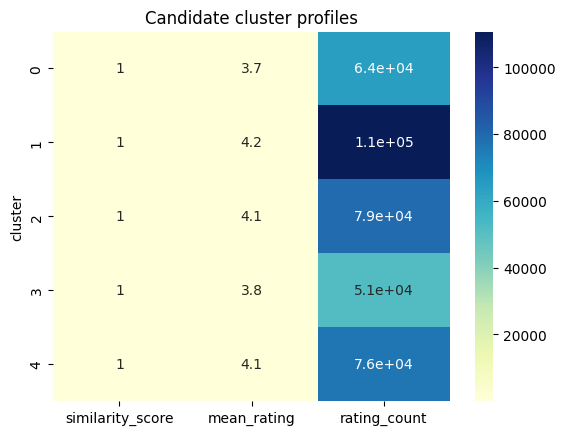

In [16]:
cluster_profile = candidate_clustered.groupby("cluster").agg(
    similarity_score=("similarity_score", "mean"),
    mean_rating=("mean_rating", "mean"),
    rating_count=("rating_count", "mean"),
)

sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu")
plt.title("Candidate cluster profiles")
plt.show()


## Visualize the Candidate Pool in Two Dimensions


In [ ]:
candidate_2d = TruncatedSVD(n_components=2).fit_transform(candidate_features)
plot_df = pd.DataFrame(
    {
        "component_1": candidate_2d[:, 0],
        "component_2": candidate_2d[:, 1],
        "cluster": candidate_clusters,
        "title": candidate_pool["title"],
    }
)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="component_1", y="component_2", hue="cluster", s=60, palette="tab10")
plt.title("Candidate pool projected with TruncatedSVD")
plt.tight_layout()
plt.show()


## Appendix: KMeans Intuition with **make_blobs**


In [ ]:
X_blob, y_blob = make_blobs(n_samples=500, centers=4, cluster_std=1.0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [3, 4, 6]):
    blob_model = KMeans(n_clusters=k, n_init=10)
    labels = blob_model.fit_predict(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, s=18, cmap="tab10", alpha=0.8)
    ax.set_title(f"KMeans with k={k}")
plt.tight_layout()
plt.show()


## Try Another Movie Title


In [ ]:
another_title = "Matrix"
recommender.recommend(another_title)
